# Regresión Lineal

## Objetivo

En este notebook se desarrolla un modelo de regresión lineal para analizar y predecir la **concentración de ozono** a partir de diferentes variables del conjunto de datos.

El análisis incluye:
- Exploración y visualización de los datos.
- Análisis de correlación entre variables.
- Entrenamiento de un modelo de regresión lineal.
- Evaluación mediante predicciones y residuos.
- Análisis de coeficientes y errores.
- Comparación con un árbol de decisión y mínimos cuadrados.

## Flujo del análisis

1. Importación de librerías.
2. Carga y exploración del conjunto de datos.
3. Análisis de relaciones entre variables.
4. Preparación de datos para el modelo.
5. Entrenamiento de la regresión lineal.
6. Evaluación del modelo.
7. Análisis complementario con datos artificiales.
8. Árbol de decisión y mínimos cuadrados.

## 1. Importación de librerías

Se importan las principales librerías utilizadas para el análisis, visualización y construcción de los modelos de regresión.

In [1]:
import numpy as np                # Cálculos números y manejo de arreglos / matrices
import pandas as pd               # Organizar, limpiar y analizar datos en forma de tablas
import matplotlib.pyplot as plt   # Crear gráficos.
import seaborn as sns	            # Crear gráficos estadísticos más elaborados y visualmente agradables.
%matplotlib inline
# Hace que los gráficos de Matplotlib aparezcan dentro de la celda de Colab/Jupyter

### Importamos el conjunto de datos

In [2]:
df = pd.read_csv("ad_viz_plotval_data_2022.csv")
df.head() # Vemos los 5 primeros datos del DataFrame

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,60750005,1,0.029,ppm,27,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044
1,01/02/2022,AQS,60750005,1,0.029,ppm,27,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044
2,01/03/2022,AQS,60750005,1,0.032,ppm,30,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044
3,01/04/2022,AQS,60750005,1,0.032,ppm,30,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044
4,01/05/2022,AQS,60750005,1,0.025,ppm,23,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044


#### Exploración inicial

Se revisan los primeros registros del conjunto de datos para conocer la estructura y las variables disponibles.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date                                  355 non-null    object 
 1   Source                                355 non-null    object 
 2   Site ID                               355 non-null    int64  
 3   POC                                   355 non-null    int64  
 4   Daily Max 8-hour Ozone Concentration  355 non-null    float64
 5   Units                                 355 non-null    object 
 6   Daily AQI Value                       355 non-null    int64  
 7   Local Site Name                       355 non-null    object 
 8   Daily Obs Count                       355 non-null    int64  
 9   Percent Complete                      355 non-null    float64
 10  AQS Parameter Code                    355 non-null    int64  
 11  AQS Parameter Descr

#### Información del conjunto de datos

Se verifica el número de registros, las variables disponibles y los tipos de datos utilizados.

### Estadísticas descriptivas

Se obtienen medidas estadísticas básicas para conocer la distribución de las variables, como el promedio, desviación estándar, valores mínimos y máximos.

- Describe round

In [4]:
df.describe().round(1)

,Site ID,POC,Daily Max 8-hour Ozone Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0
mean,60750005.0,1.0,0.0,26.8,17.0,99.8,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
std,0.0,0.0,0.0,7.3,0.3,1.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,60750005.0,1.0,0.0,8.0,13.0,76.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
25%,60750005.0,1.0,0.0,21.0,17.0,100.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
50%,60750005.0,1.0,0.0,27.0,17.0,100.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
75%,60750005.0,1.0,0.0,32.0,17.0,100.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
max,60750005.0,1.0,0.1,67.0,17.0,100.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4


#### Interpretación

Las estadísticas descriptivas permiten identificar el rango de valores de cada variable y observar posibles diferencias en su distribución.

### Análisis exploratorio de los datos

El siguiente gráfico permite observar visualmente las relaciones entre las diferentes variables del conjunto de datos.

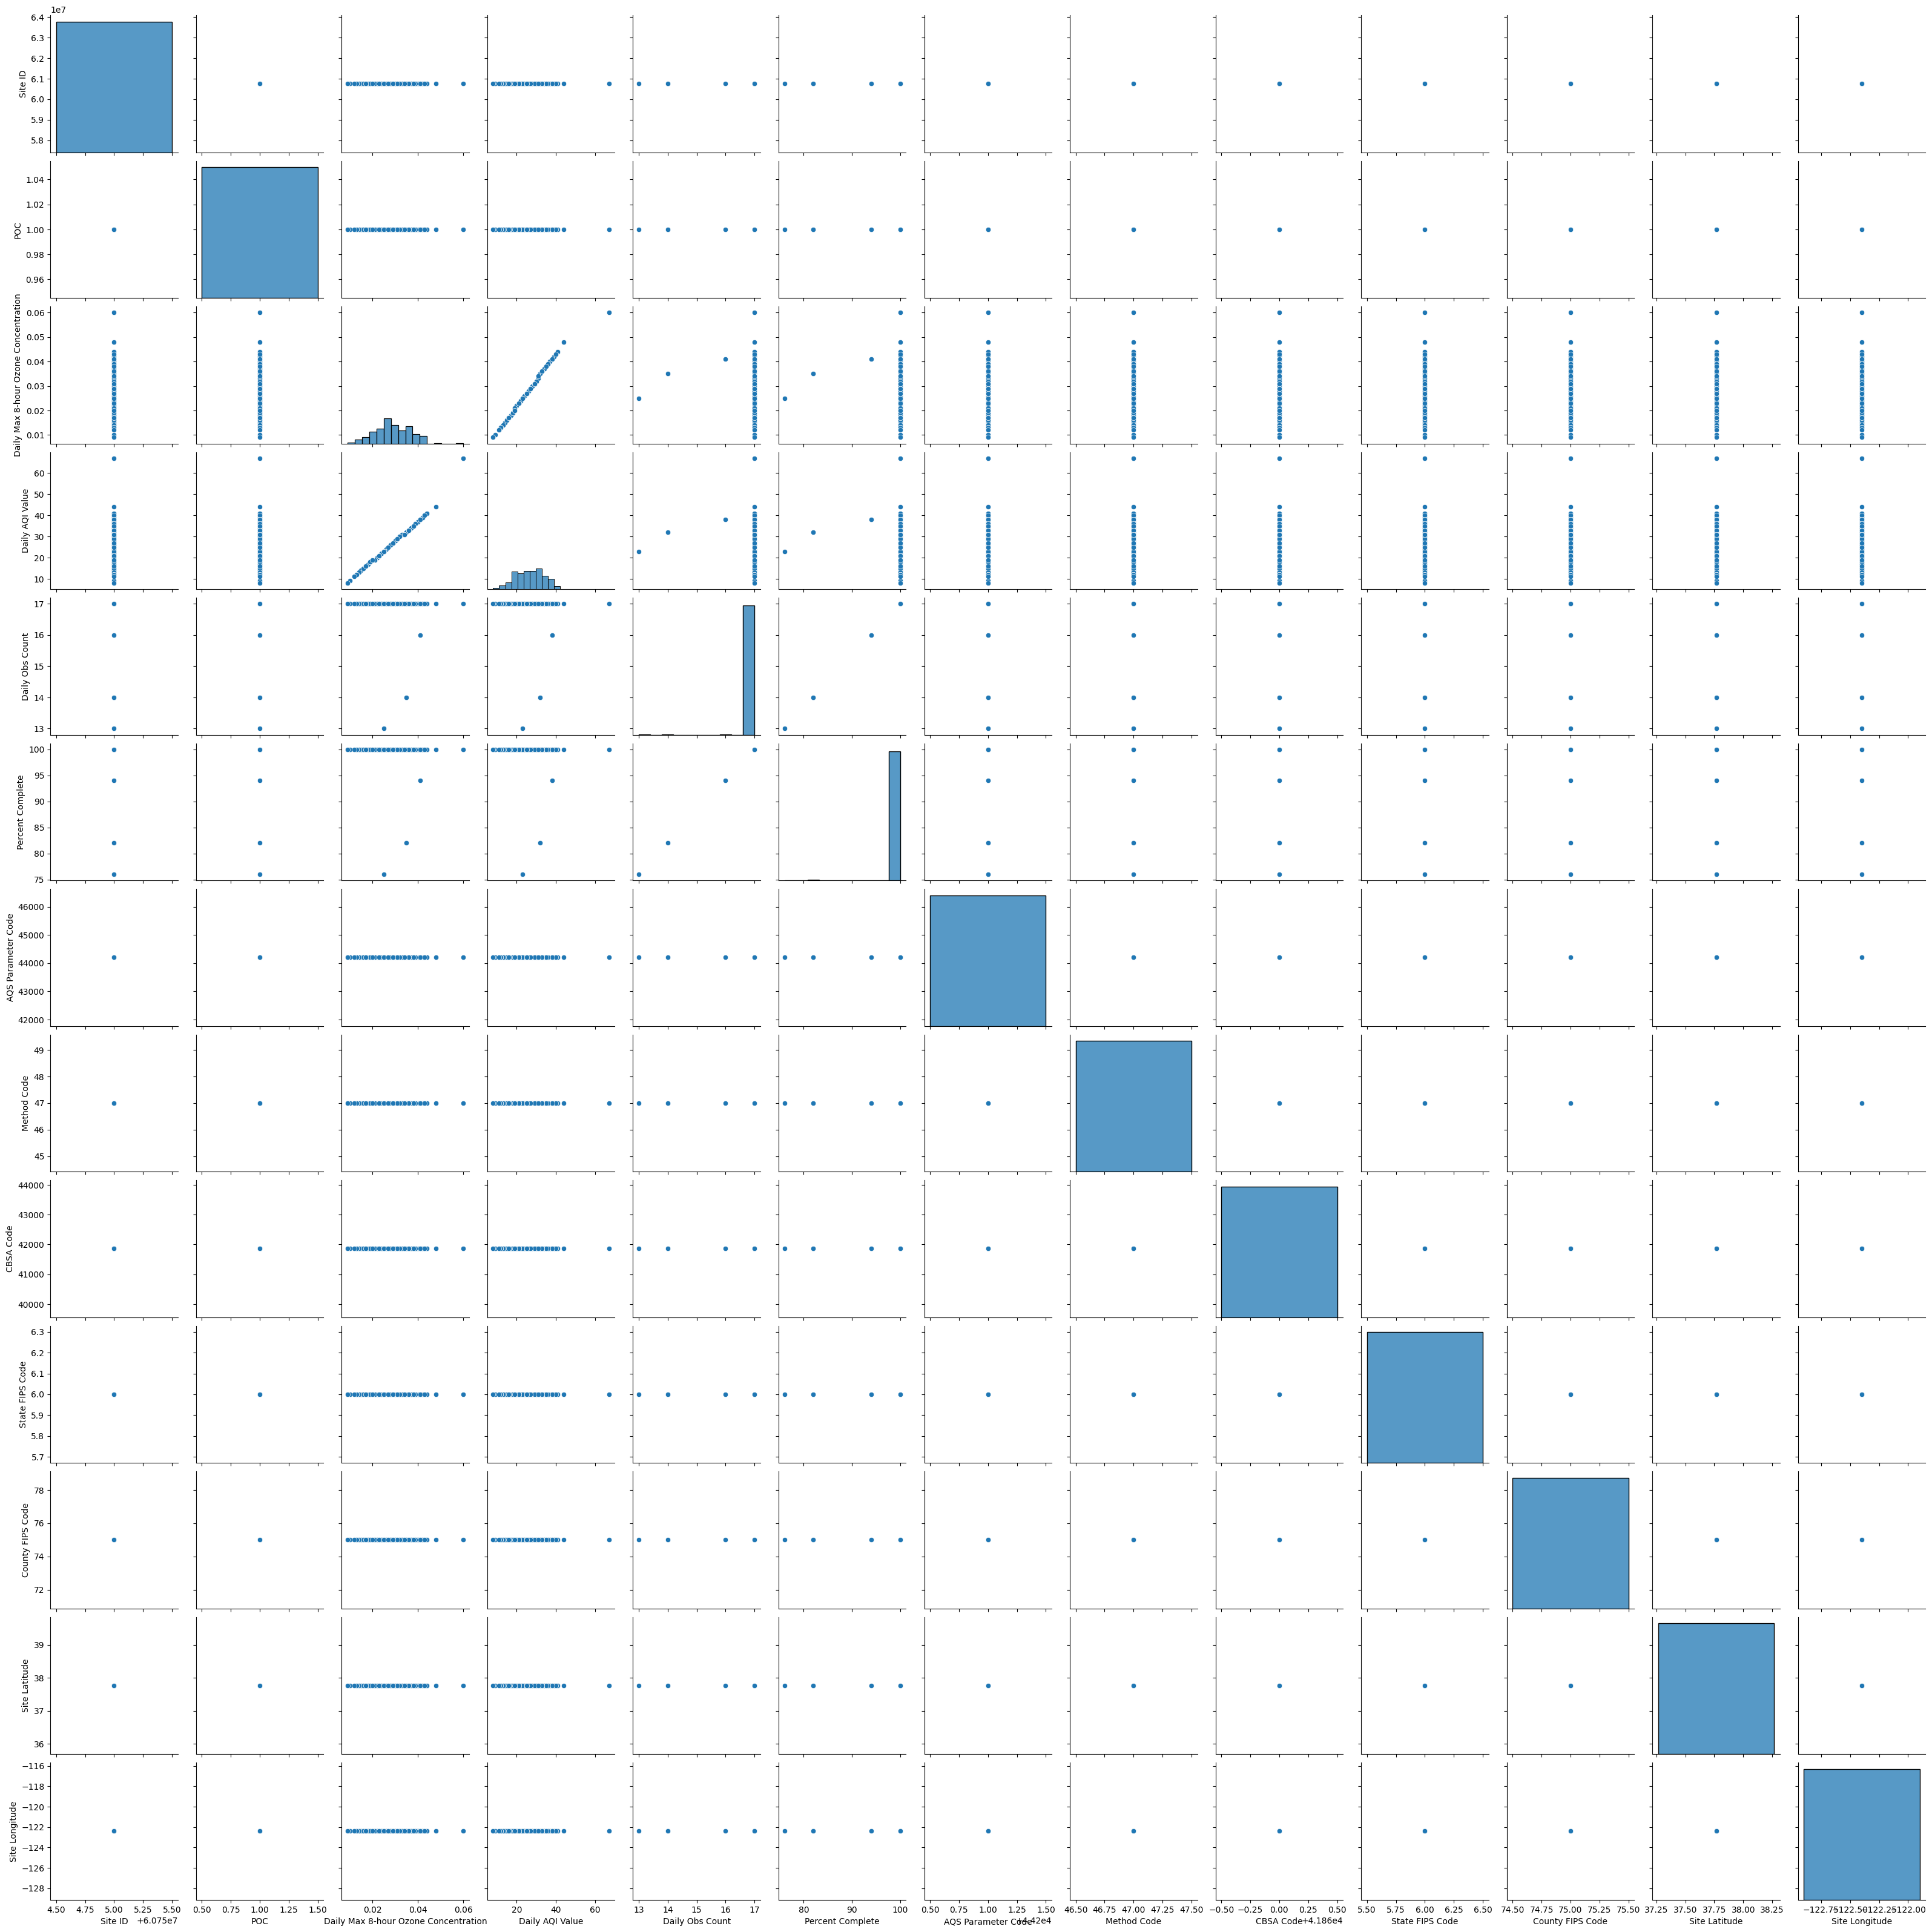

In [5]:
sns.pairplot(df)

#### Observación

El gráfico permite identificar posibles relaciones lineales, tendencias y distribuciones entre las variables.

### Distribución del consumo de energía

Se analiza la distribución de la variable objetivo **Consumo_Energia** mediante un histograma y una curva de densidad.

' Histograma: ¿Cómo se distribuyen los datos por intervalos? '

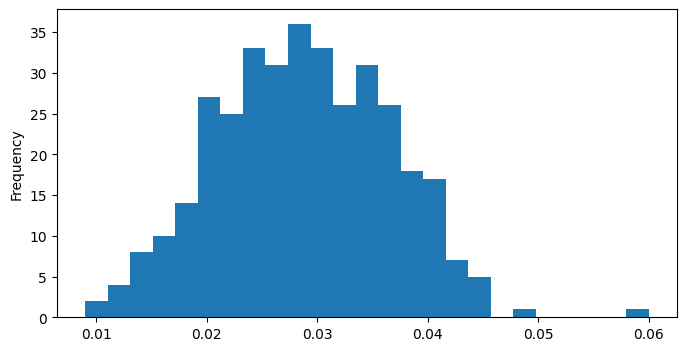

In [6]:
df['Daily Max 8-hour Ozone Concentration'].plot.hist(bins=25, figsize=(8,4))
# Histograma en 25 intervalos
''' Histograma: ¿Cómo se distribuyen los datos por intervalos? '''
#figsize(ancho, alto): tamaño de la figura


'\nDensidad: ¿Dónde están concentrados los datos?\n'

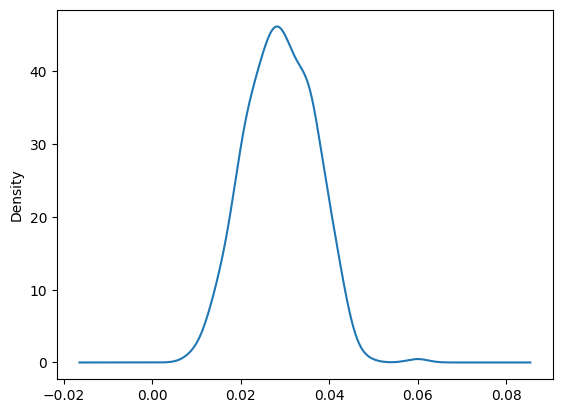

In [7]:
df['Daily Max 8-hour Ozone Concentration'].plot.density()
'''
Densidad: ¿Dónde están concentrados los datos?
'''

### Análisis de correlación

Se calcula la correlación entre las variables numéricas para identificar cuáles presentan una relación más fuerte con el consumo de energía.

In [8]:
numeric_df1 = df.select_dtypes(include=[np.number])
# Selecciona solo las columnas con valores numéricos

numeric_df1.corr().round(4)
# Cálculo de la correlación

,Site ID,POC,Daily Max 8-hour Ozone Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
Site ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Max 8-hour Ozone Concentration,NaN,NaN,1.0000,0.9958,-0.0387,-0.0387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily AQI Value,NaN,NaN,0.9958,1.0000,-0.0341,-0.0341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Obs Count,NaN,NaN,-0.0387,-0.0341,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Percent Complete,NaN,NaN,-0.0387,-0.0341,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AQS Parameter Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Method Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CBSA Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State FIPS Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


'\nHoras de operación > 0.84\nEstá bastante cerca de +1, por lo que existe una fuerte relación lineal positiva.\n>>> A medida que aumentan las horas de operación, tiene a aumentar el consumo energético.\n\nCarga > 0.34\nEs una relacion positiva moderada / baja\n>>> Cuando aumenta la carga, el consumo tiende a aumentar.\n\nTemperatura > 0.098\nEs una relación muy débil\n\nHumedad > 0.063\nTambién es una relación muy débil, practicamente cercana a cero.\n\n'

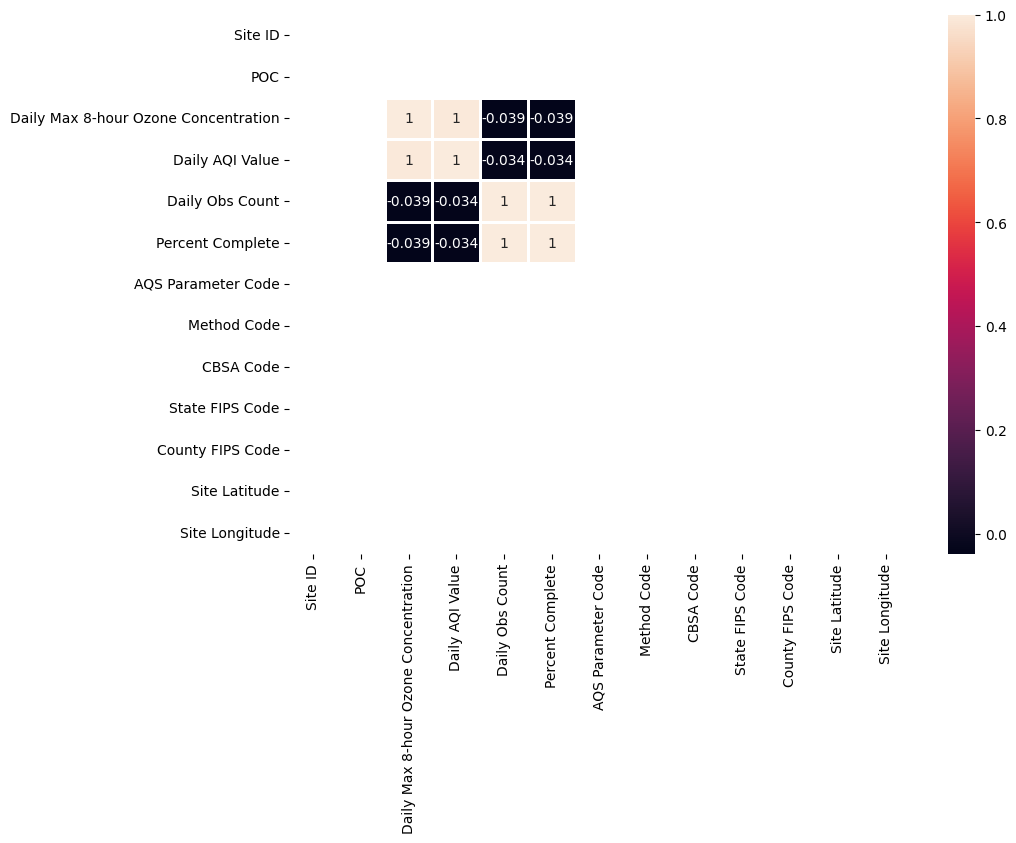

In [9]:
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df1.corr(), annot=True, linewidths=2)

# Mapa de calor de correlaciones
'''
Horas de operación > 0.84
Está bastante cerca de +1, por lo que existe una fuerte relación lineal positiva.
>>> A medida que aumentan las horas de operación, tiene a aumentar el consumo energético.

Carga > 0.34
Es una relacion positiva moderada / baja
>>> Cuando aumenta la carga, el consumo tiende a aumentar.

Temperatura > 0.098
Es una relación muy débil

Humedad > 0.063
También es una relación muy débil, practicamente cercana a cero.

'''

#### Interpretación de la correlación

- **Horas de operación:** presenta una relación lineal positiva fuerte con el consumo de energía.
- **Carga:** presenta una relación positiva moderada/baja.
- **Temperatura:** presenta una relación muy débil.
- **Humedad:** presenta una relación muy débil.

Por lo tanto, las **horas de operación** destacan como la variable con mayor relación lineal con el consumo de energía.

### Conjuntos de caraceterísticas y variables

#### Preparación de las variables

Se separan las variables utilizadas como características de entrada (**x**) y la variable que se desea predecir (**y**).

- **x:** variables independientes utilizadas para realizar las predicciones.
- **y:** variable objetivo, correspondiente a la concentración de ozono.

In [10]:
l_column = list(df.columns)
len_feature = len(l_column)
l_column

['Date',
 'Source',
 'Site ID',
 'POC',
 'Daily Max 8-hour Ozone Concentration',
 'Units',
 'Daily AQI Value',
 'Local Site Name',
 'Daily Obs Count',
 'Percent Complete',
 'AQS Parameter Code',
 'AQS Parameter Description',
 'Method Code',
 'CBSA Code',
 'CBSA Name',
 'State FIPS Code',
 'State',
 'County FIPS Code',
 'County',
 'Site Latitude',
 'Site Longitude']

### Regresión lineal

Se utilizará un modelo de regresión lineal para estudiar la relación entre las variables de entrada y la **concentración de ozono**.

El modelo busca encontrar una combinación lineal de las variables que permita estimar la concentración de ozono.

In [11]:
x = df[['Daily AQI Value', 'Daily Obs Count', 'Percent Complete']]
y = df['Daily Max 8-hour Ozone Concentration']

x.head()

,Daily AQI Value,Daily Obs Count,Percent Complete
0,27,17,100.0
1,27,17,100.0
2,30,17,100.0
3,30,17,100.0
4,23,17,100.0


In [12]:
y.head()

,Daily Max 8-hour Ozone Concentration
0,0.029
1,0.029
2,0.032
3,0.032
4,0.025


### División de los datos

Los datos se dividen en dos grupos:

- **70 % para entrenamiento:** utilizado para ajustar el modelo.
- **30 % para prueba:** utilizado para evaluar su comportamiento con datos que no fueron utilizados durante el entrenamiento.

Se utiliza `random_state=123` para mantener reproducible la división.

In [13]:
from sklearn.model_selection import train_test_split
# divide datos en: entrenamiento y prueba

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=123
    )

### Ajuste y entrenamiento del modelo

Se crea un modelo de regresión lineal y se ajusta utilizando los datos de entrenamiento.

Durante este proceso, el modelo estima los coeficientes que relacionan las variables de entrada con el consumo de energía.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [16]:
lm = LinearRegression()

In [17]:
lm.fit(x_train, y_train) # Ajustar y entrenar

LinearRegression()

In [18]:
# Verificamos la intercepción
print(lm.intercept_)

0.001051014233913107


In [19]:
# Verificamos el modelo lineal
print(lm.coef_)

[ 1.08461850e-03 -1.89529334e-06 -1.13717600e-05]


#### Interpretación de los coeficientes

Los coeficientes indican cómo cambia el consumo de energía cuando una variable de entrada aumenta una unidad, manteniendo constantes las demás variables.

El signo del coeficiente indica la dirección de la relación:

- Coeficiente positivo → el consumo estimado aumenta.
- Coeficiente negativo → el consumo estimado disminuye.
- Un valor cercano a cero → menor influencia lineal dentro del modelo.

In [20]:
cdf = pd.DataFrame(lm.coef_, x.columns, columns=['Coefficients'])
cdf

,Coefficients
Daily AQI Value,0.001085
Daily Obs Count,-0.000002
Percent Complete,-0.000011


### Cálculo de errores estándar y estadística t para los coeficientes

In [21]:
n = x_train.shape[0]                    # Cantidad de datos de entrenamiento
k = x_train.shape[1]                    # Cantidad de variables: 3
dfN = n-k                               # grados de libertad
train_pred = lm.predict(x_train)        # Obtener predicciones

# Cálculamos el error: R^2
train_error = np.square(train_pred - y_train) # comparamos (predicción - valor real)^2
sum_error = np.sum(train_error)

se = [0,0,0]
for i in range(k):
  r = (sum_error/dfN)
  # Calcula la variabilidad de cada variable respecto a su promedio
  r = r/np.sum(np.square(x_train[list(x_train.columns)[i]] - x_train[list(x_train.columns)[i]].mean()))
  se[i] = np.sqrt(r) # cálculo del error estándar

cdf['Standard Error']=se
cdf['t-statistic']=cdf['Coefficients']/cdf['Standard Error']

cdf

,Coefficients,Standard Error,t-statistic
Daily AQI Value,0.001085,0.000003,382.450691
Daily Obs Count,-0.000002,0.000061,-0.031189
Percent Complete,-0.000011,0.000010,-1.122821


#### Evaluación estadística de los coeficientes

Se calculan medidas adicionales para analizar la incertidumbre asociada a los coeficientes estimados por el modelo.

Estos cálculos permiten complementar el análisis de la regresión y evaluar el comportamiento estadístico de las variables utilizadas.

### Relación entre las variables y la concentración de ozono

Se generan gráficos de dispersión para visualizar la relación entre cada característica y la concentración de ozono.

Estas visualizaciones permiten complementar el análisis de correlación realizado anteriormente.

Text(0.5, 1.0, 'Percent Complete vs. Concentración de ozono')

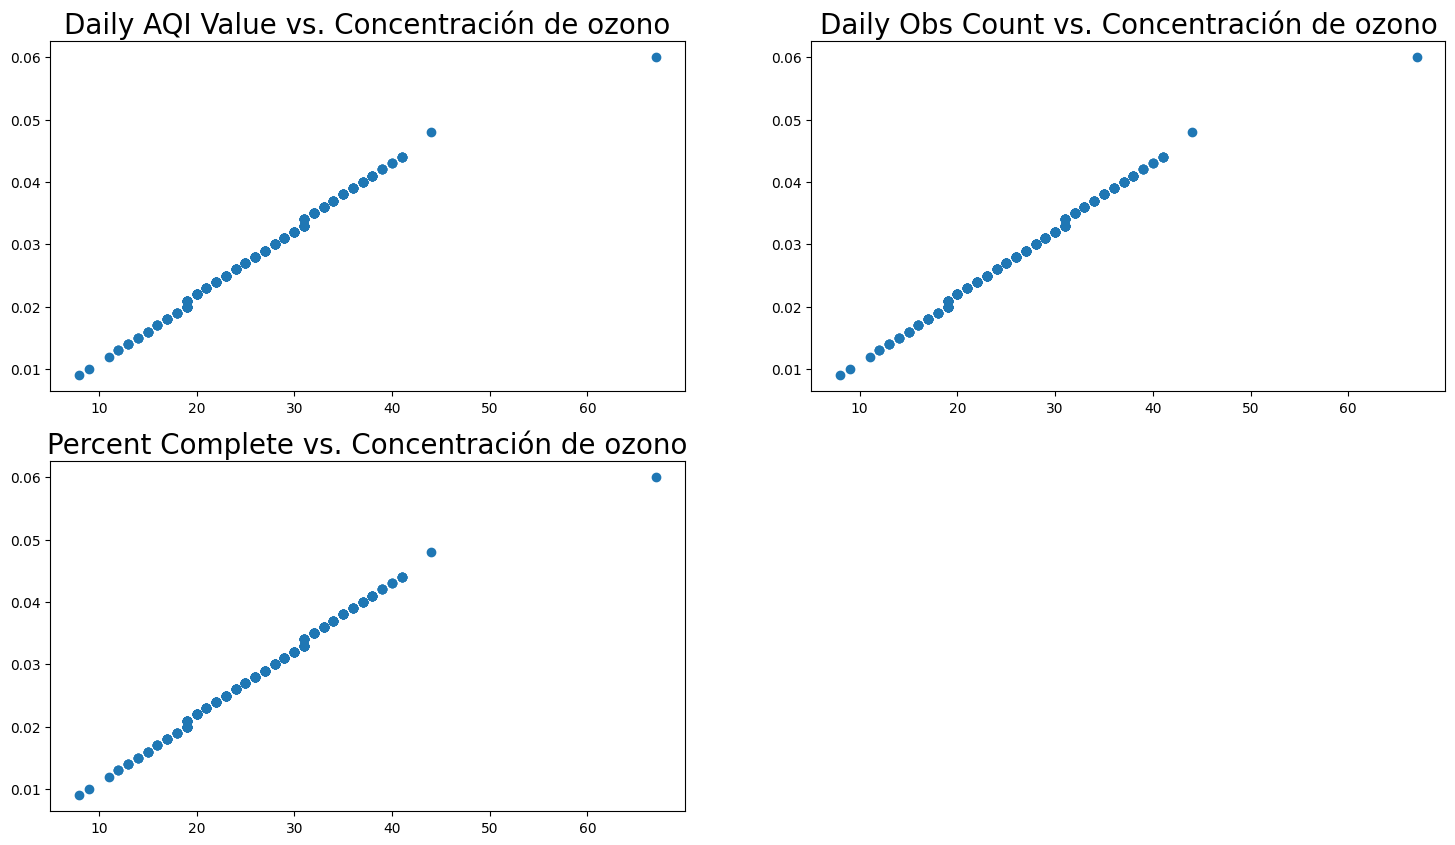

In [22]:
l = list(cdf.index)

from matplotlib import gridspec
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

ax0 = plt.subplot(gs[0])
ax0.scatter(df[l[0]], df['Daily Max 8-hour Ozone Concentration'])
ax0.set_title(l[0] + " vs. Concentración de ozono", fontdict={'fontsize':20})

ax1 = plt.subplot(gs[1])
ax1.scatter(df[l[0]], df['Daily Max 8-hour Ozone Concentration'])
ax1.set_title(l[1] + " vs. Concentración de ozono", fontdict={'fontsize':20})

ax2 = plt.subplot(gs[2])
ax2.scatter(df[l[0]], df['Daily Max 8-hour Ozone Concentration'])
ax2.set_title(l[2] + " vs. Concentración de ozono", fontdict={'fontsize':20})

###

In [23]:
predictions = lm.predict(x_test)
print("Tipo del objeto predicho: ", type(predictions))
print("Tamaño del objeto predicho: ", predictions.shape)


Tipo del objeto predicho:  <class 'numpy.ndarray'>
Tamaño del objeto predicho:  (107,)


#### Evaluación de las predicciones

Se utilizan los datos de prueba para generar predicciones de la concentración de ozono.

Posteriormente se comparan los valores reales con los valores predichos para evaluar visualmente el comportamiento del modelo.

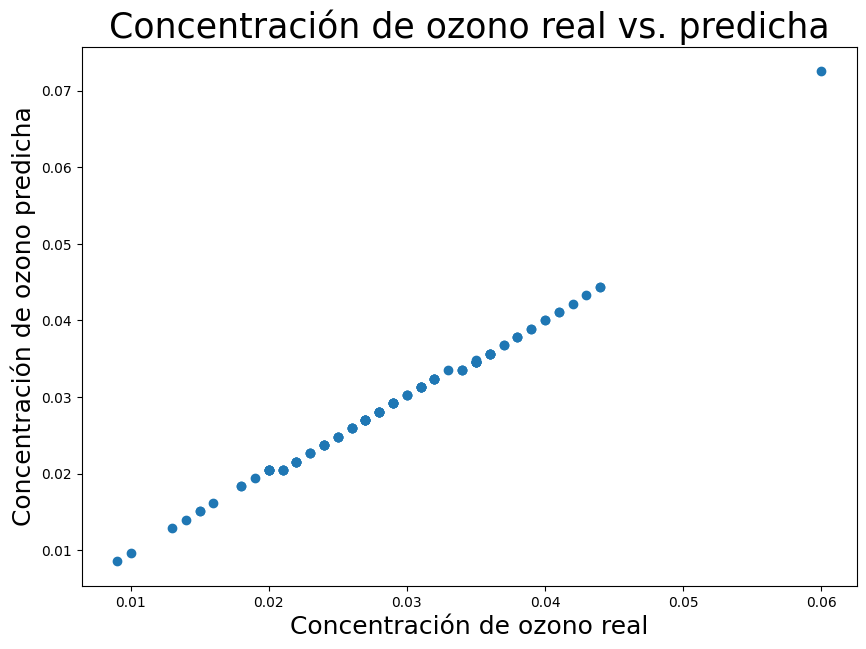

In [24]:
# Diagrama de dispersión
''' Meta: Datos caen en una línea recta de 45 '''

plt.figure(figsize=(10,7))
plt.title("Concentración de ozono real vs. predicha", fontsize=25)
plt.xlabel("Concentración de ozono real", fontsize=18)
plt.ylabel("Concentración de ozono predicha", fontsize=18)
plt.scatter(x=y_test, y=predictions)

### Análisis de residuos

Los residuos representan la diferencia entre el valor real y el valor predicho por el modelo.

Su análisis permite identificar posibles patrones que indiquen problemas en el ajuste de la regresión.

/tmp/ipykernel_11221/3524158693.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([y_test-predictions])


<Axes: title={'center': 'Residuos'}, xlabel='Concentración de ozono real', ylabel='Residuos'>

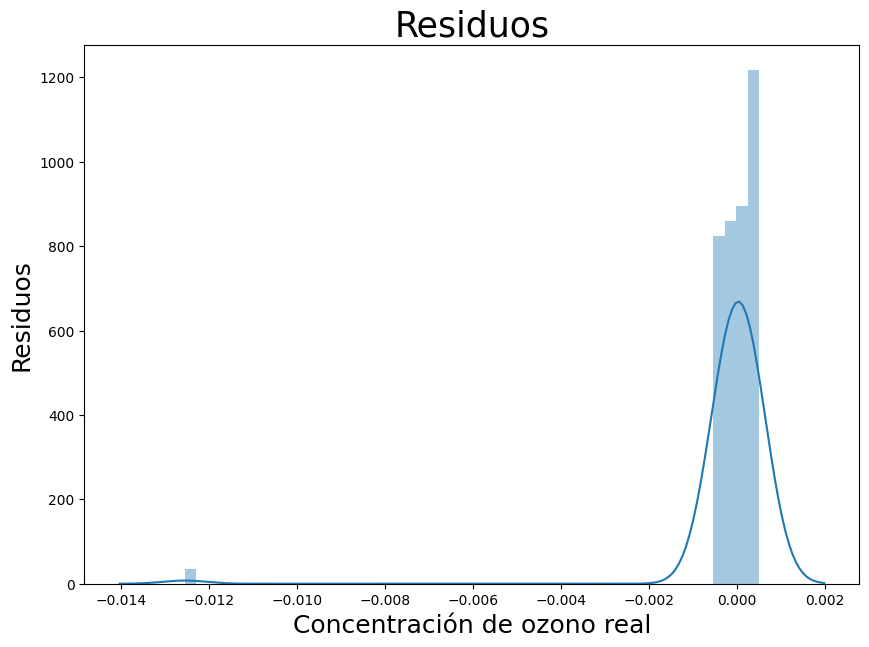

In [25]:
plt.figure(figsize=(10,7))
plt.title("Residuos", fontsize=25)
plt.xlabel("Concentración de ozono real", fontsize=18)
plt.ylabel("Residuos", fontsize=18)
sns.distplot([y_test-predictions])

#### Interpretación

Se observa la distribución de los residuos para analizar cómo se distribuyen los errores del modelo.

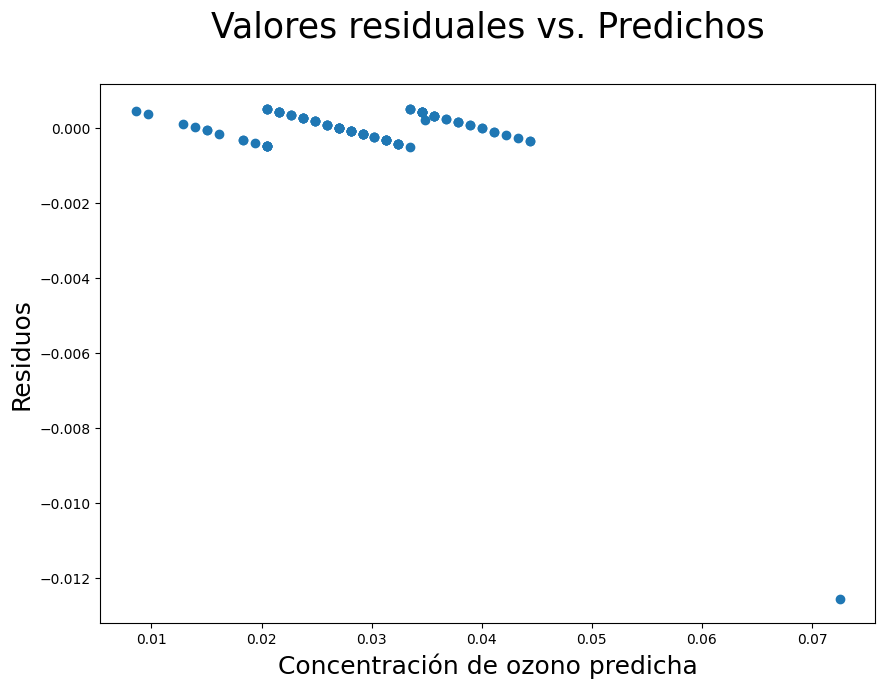

In [26]:
# Diagrama de dispersión (Homoscedasticidad)

plt.figure(figsize=(10,7))
plt.title("Valores residuales vs. Predichos\n", fontsize=25)
plt.xlabel("Concentración de ozono predicha", fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions, y=y_test-predictions)

## Análisis complementario

A continuación se realiza un análisis adicional utilizando un conjunto de datos artificiales generado con `make_regression`.

Esta sección permite experimentar con otros modelos y analizar la importancia de las características.

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np


### Generación de datos artificiales

Se generan datos sintéticos con varias características, de las cuales solamente algunas son consideradas informativas para la variable objetivo.

In [28]:
# Importar el método make_regression para generar muestras de datos artificiales
from sklearn.datasets import make_regression

n_samples = 100 # Número de muestras
n_features = 6 # Número de características
n_informative = 3 # Número de características informativas i.e. características reales que influyen en la salida


In [29]:

x, y, coef = make_regression(n_samples=n_samples, n_features=n_features, n_informative=n_informative,
                             random_state=20, shuffle=False, noise=20, coef=True)
#                     semilla aleatoria (reproducibilidad)
#                     que no se mezclen las características
#                     ruido aleatorio
#                     devuelve los coef.
print(coef)

[78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


### Creación del dataframe y visualizaciones básicas

In [30]:
df1 = pd.DataFrame(data=x, columns=['x' + str(i) for i in range(1, n_features+1)])
df2 = pd.DataFrame(data=y, columns=['y'])
df = pd.concat([df1, df2], axis=1)
df.head(10)

,x1,x2,x3,x4,x5,x6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


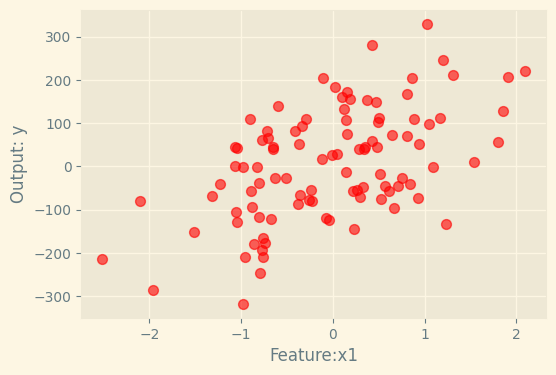

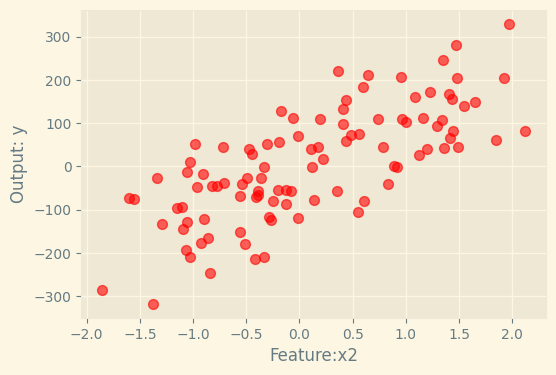

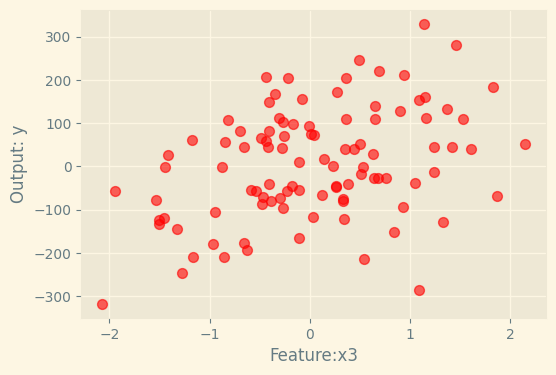

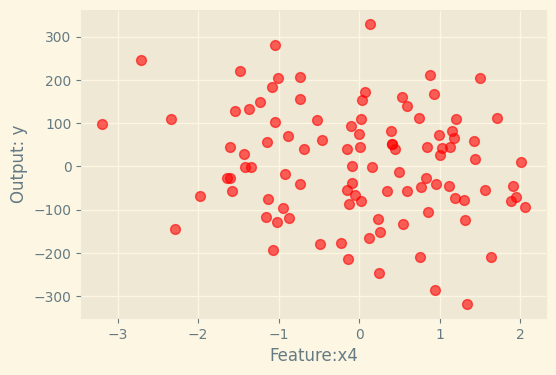

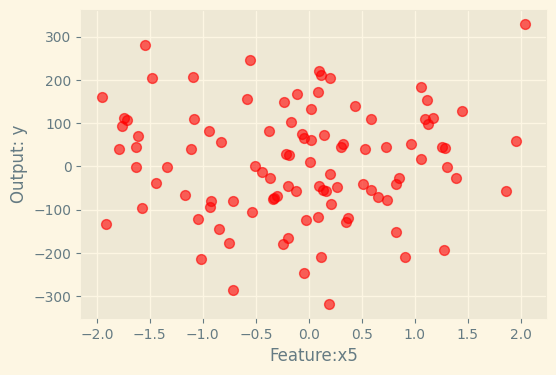

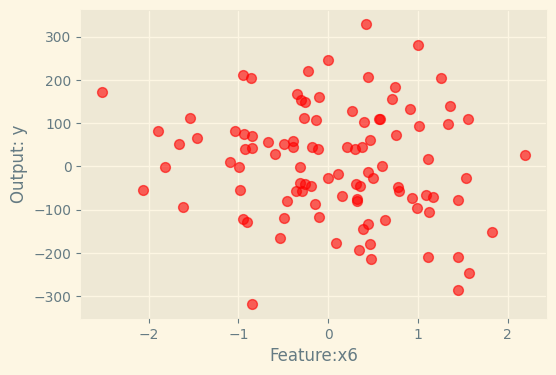

In [31]:
with plt.style.context(('Solarize_Light2')):
    for i, col in enumerate(df.columns[:-1]):
        plt.figure(figsize=(6, 4))
        plt.grid(True)
        plt.xlabel('Feature:' + col, fontsize=12)
        plt.ylabel('Output: y', fontsize=12)
        plt.scatter(df[col], df['y'], c='red', s=50, alpha=0.6)

### Árbol de decisión para regresión

Como análisis complementario, se utiliza un árbol de decisión para realizar predicciones sobre los datos artificiales.

También se analiza la importancia relativa de las características utilizadas por el modelo.

In [32]:
from sklearn import tree
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=123
)

# Creación del modelo
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
# niveles de decisión
tree_model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=10)

Mean square error (MSE): 7931.574768958281


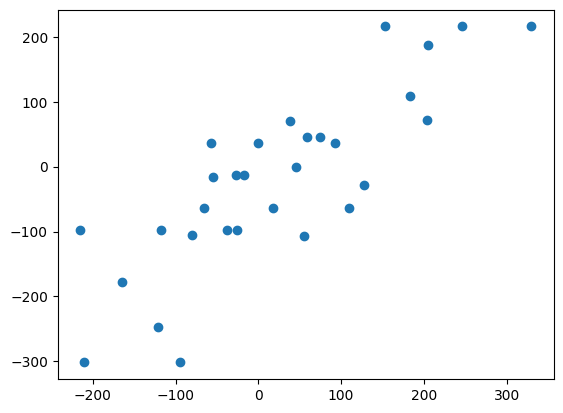

In [33]:
from sklearn import metrics

# Hacemos predicciones
test_pred = tree_model.predict(x_test)
plt.scatter(x=y_test, y=test_pred)  # real vs predicho
print("Mean square error (MSE):", metrics.mean_squared_error(y_test, test_pred))
# Error cuadrático medio

Importancia relativa de las características:  [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


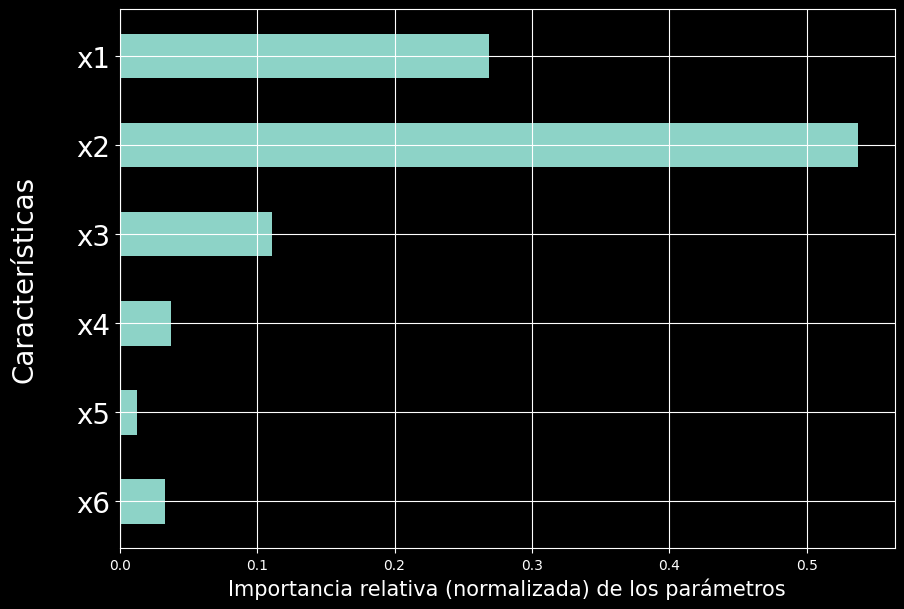

In [34]:
print("Importancia relativa de las características: ", tree_model.feature_importances_)
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features+1, 1, -1), df.columns[:-1], fontsize=20)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features+1, 1, -1), width=tree_model.feature_importances_, height=0.5)

#### Importancia de las características

La importancia relativa permite identificar qué características tienen mayor influencia en las predicciones realizadas por el árbol de decisión.

### Mínimos cuadrados



Se utiliza el método de mínimos cuadrados mediante `statsmodels` para ajustar un modelo lineal y obtener un resumen estadístico de sus resultados.

El resumen permite analizar los coeficientes, errores y diferentes medidas estadísticas del modelo.

In [35]:
import statsmodels.api as sm

In [36]:
Xs = sm.add_constant(x)
stat_model = sm.OLS(y, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        20:49:50   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0

## Conclusiones

- Se realizó un análisis exploratorio del conjunto de datos y de las relaciones entre sus variables.
- El análisis de correlación permitió identificar las variables que presentan mayor relación con la concentración de ozono.
- Se entrenó un modelo de regresión lineal utilizando una división de datos de entrenamiento y prueba.
- Las predicciones y el análisis de residuos permitieron evaluar visualmente el comportamiento del modelo.
- Finalmente, se realizó un análisis complementario utilizando datos artificiales, un árbol de decisión y el método de mínimos cuadrados.